# WLASL Sign Language Recognition with CNN-Mamba

This notebook implements a **MobileNetV3-Large + Selective State Space Model (Mamba)** architecture for real-time word-level American Sign Language (ASL) recognition on the WLASL dataset.

**Architecture:**
- **Spatial Encoder:** MobileNetV3-Large (ImageNet pretrained)
- **Temporal Decoder:** 2-layer selective SSM (Mamba)
- **Input:** 25 frames × 224 × 224 RGB (1 second at 25 fps)
- **Output:** 300 ASL gloss classes (WLASL300 subset)

**Key Properties:**
- Linear-time temporal complexity: O(n)
- Fixed memory state during inference (no KV cache growth)
- ~6M parameters, suitable for edge deployment

## 1. Setup and Imports

In [1]:
# Install required packages (run once)
!pip install -q opencv-python scikit-learn seaborn huggingface_hub

# Hugging Face login (must complete before proceeding)
from huggingface_hub import notebook_login
notebook_login()

import os
import sys
import json
import time
import random
import gc
import numpy as np
import pandas as pd
import cv2
import psutil
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v3_large

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Configuration

Dataset paths use a dual-source fallback system: primary videos from `wlasl-processed` with automatic fallback to `wlasl2000-resized` for missing files.

In [2]:
# Configuration
import pathlib

# Detect environment
KAGGLE = pathlib.Path('/kaggle/input').exists()
BASE_DIR = pathlib.Path('/kaggle') if KAGGLE else pathlib.Path('..')
print(f"Running on {'Kaggle' if KAGGLE else 'Local'} environment")
print(f"BASE_DIR: {BASE_DIR.resolve()}")

class Config:
    # Dataset
    NUM_CLASSES = 300          # WLASL300 (or 100, 1000, 2000)
    NUM_FRAMES = 16            # Frames used by the model (after jitter subsampling)
    NUM_FRAMES_PRELOAD = 25    # Frames extracted per video (uniform sampling, for temporal jitter)
    FRAME_SIZE = 224           # Spatial resolution

    # Data Augmentation
    JITTER_ENABLED = True      # Enable temporal jitter (random start frame) in training
    JITTER_STRIDE = 1          # Stride between subsampled frames (1 = consecutive)
    
    # Model
    D_MODEL = 256              # Mamba hidden dimension
    D_STATE = 16               # SSM state dimension
    N_MAMBA_LAYERS = 2         # Number of Mamba blocks
    DROPOUT = 0.6
    
    # Training
    BATCH_SIZE = 16
    NUM_EPOCHS = 100
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-4
    PATIENCE = 10              # Early stopping patience
    
    # Paths
    if KAGGLE:
        JSON_PATH = '/kaggle/input/datasets/risangbaskoro/wlasl-processed/WLASL_v0.3.json'
        VIDEO_ROOT = '/kaggle/input/datasets/risangbaskoro/wlasl-processed/videos'
        VIDEO_ROOT_BACKUP = '/kaggle/input/datasets/sttaseen/wlasl2000-resized/wlasl-complete/videos'
        CHECKPOINT_DIR = '/kaggle/working/checkpoints'
        FRAMES_ROOT = '/kaggle/working/frames_npy'
        MANIFEST_PATH = '/kaggle/working/frames_manifest.json'
        TOP_300_CSV = '/kaggle/working/wlasl300_class_distribution.csv'
    else:
        # Local: all data lives under BASE_DIR/data/
        JSON_PATH = str(BASE_DIR / 'data/WLASL_v0.3.json')
        VIDEO_ROOT = str(BASE_DIR / 'data/videos')
        VIDEO_ROOT_BACKUP = str(BASE_DIR / 'data/videos_backup')
        CHECKPOINT_DIR = str(BASE_DIR / 'data/checkpoints')
        FRAMES_ROOT = str(BASE_DIR / 'data/frames_npy')
        MANIFEST_PATH = str(BASE_DIR / 'data/frames_manifest.json')
        TOP_300_CSV = str(BASE_DIR / 'data/wlasl300_class_distribution.csv')
    # Reproducibility
    SEED = 42

    # Hugging Face
    HF_REPO_ID = "pandafm/cv2-proyecto-mamba"  # HF repo for model checkpoints
    HF_UPLOAD = True  # Enable upload to Hugging Face

# Create directories
os.makedirs(Config.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(Config.FRAMES_ROOT, exist_ok=True)

# Set random seeds
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(Config.SEED)

# Check what's available for skipping
manifest_exists = pathlib.Path(Config.MANIFEST_PATH).exists()
model_exists = pathlib.Path(str(BASE_DIR / 'data/checkpoints/best_model.pth')).exists()
frames_exist = pathlib.Path(Config.FRAMES_ROOT).exists() and len(list(pathlib.Path(Config.FRAMES_ROOT).glob('*.npy'))) > 0

print(f"\nAvailable resources:")
print(f"  Manifest:       {'YES' if manifest_exists else 'NO'}  ({Config.MANIFEST_PATH})")
print(f"  Model weights:  {'YES' if model_exists else 'NO'}  (data/checkpoints/best_model.pth)")
print(f"  Frames (.npy):  {'YES' if frames_exist else 'NO'}  ({Config.FRAMES_ROOT}/)")

if not KAGGLE:
    print(f"\n  Local mode: You can run Sections 8-10 (test eval + failure analysis)")
    print(f"  directly if manifest + model + frames exist.")
    print(f"  Sections 4-7 require original videos for preprocessing/training.")

print("\nConfiguration loaded successfully!")


Running on Kaggle environment
BASE_DIR: /kaggle

Available resources:
  Manifest:       NO  (/kaggle/working/frames_manifest.json)
  Model weights:  NO  (data/checkpoints/best_model.pth)
  Frames (.npy):  NO  (/kaggle/working/frames_npy/)

Configuration loaded successfully!


## 3. Data Exploration

Total glosses in full dataset: 2000

WLASL300 Statistics:
  Total videos: 5117
  Train: 3549 (69.4%)
  Val: 900 (17.6%)
  Test: 668 (13.1%)
  Classes: 300
  Instances per class: min=14, max=40, mean=17.1
Class distribution saved to '/kaggle/working/wlasl300_class_distribution.csv'!


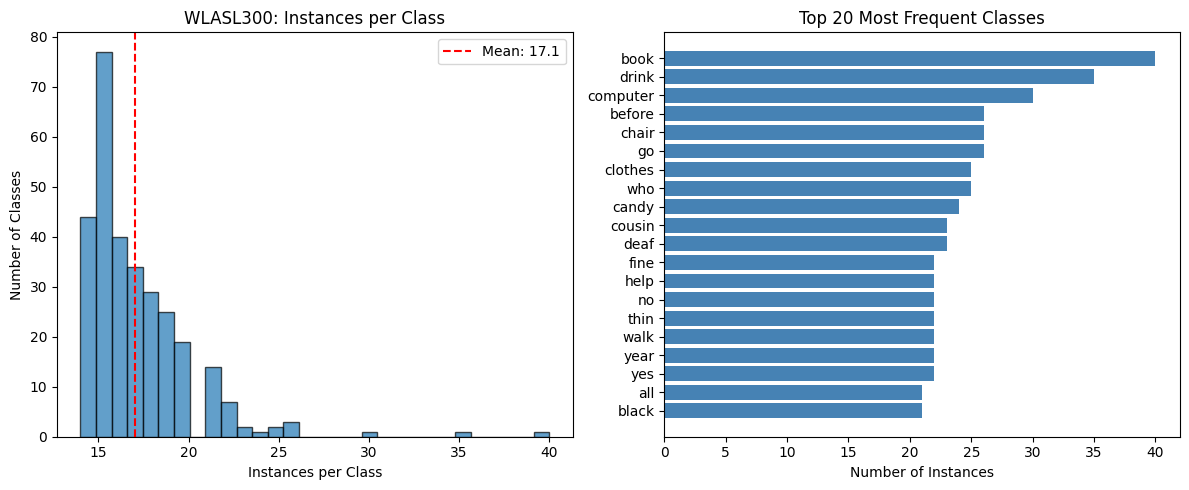


Class distribution plot saved!


In [3]:
# Load WLASL annotations
def load_wlasl_data(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    return data

data = load_wlasl_data(Config.JSON_PATH)
print(f"Total glosses in full dataset: {len(data)}")

# Get statistics for top-k classes
def analyze_subset(data, k=300):
    gloss_counts = [(entry['gloss'], len(entry['instances'])) for entry in data]
    gloss_counts.sort(key=lambda x: x[1], reverse=True)
    top_k = gloss_counts[:k]
    
    # Statistics
    subset_stats = {'train': 0, 'val': 0, 'test': 0}
    counts = []
    
    for gloss, _ in top_k:
        entry = next(e for e in data if e['gloss'] == gloss)
        class_count = {'train': 0, 'val': 0, 'test': 0, 'total': 0}
        for inst in entry['instances']:
            split = inst['split']
            subset_stats[split] += 1
            class_count[split] += 1
            class_count['total'] += 1
        counts.append(class_count['total'])
    
    total = sum(subset_stats.values())
    print(f"\nWLASL{k} Statistics:")
    print(f"  Total videos: {total}")
    print(f"  Train: {subset_stats['train']} ({subset_stats['train']/total*100:.1f}%)")
    print(f"  Val: {subset_stats['val']} ({subset_stats['val']/total*100:.1f}%)")
    print(f"  Test: {subset_stats['test']} ({subset_stats['test']/total*100:.1f}%)")
    print(f"  Classes: {k}")
    print(f"  Instances per class: min={min(counts)}, max={max(counts)}, mean={np.mean(counts):.1f}")
    
    return top_k

top_300 = analyze_subset(data, k=Config.NUM_CLASSES)

df = pd.DataFrame(top_300, columns=['gloss', 'instance_count'])
df.insert(0, 'label', df.index)  # Add label column for reliable ID mapping
df.to_csv(Config.TOP_300_CSV, index=False)
print(f"Class distribution saved to '{Config.TOP_300_CSV}'!")

# Visualize class distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
counts = [c[1] for c in top_300]
plt.hist(counts, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Instances per Class')
plt.ylabel('Number of Classes')
plt.title('WLASL300: Instances per Class')
plt.axvline(np.mean(counts), color='red', linestyle='--', label=f'Mean: {np.mean(counts):.1f}')
plt.legend()

plt.subplot(1, 2, 2)
names = [c[0] for c in top_300[:20]]
values = [c[1] for c in top_300[:20]]
plt.barh(range(len(names)), values, color='steelblue')
plt.yticks(range(len(names)), names)
plt.xlabel('Number of Instances')
plt.title('Top 20 Most Frequent Classes')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nClass distribution plot saved!")

## 4. Data Loading

In [4]:
# ============================================================
# PREPROCESSING: Extract video frames to uint8 .npy files
# ============================================================
# Run this ONCE before training to eliminate cv2/ffmpeg memory leaks.
# Frames are saved as uint8 numpy arrays (not float32) to save disk space.
# Size: 25x224x224x3 = ~3.6 MB per video (vs 7.2 MB in float32)
# Total: ~18 GB for 5117 videos (25 frames for temporal jitter support, fits Kaggle's 19 GB).

import os
import json
import gc
import cv2
import numpy as np
import torch
import psutil

FRAMES_ROOT = Config.FRAMES_ROOT
MANIFEST_PATH = Config.MANIFEST_PATH
os.makedirs(FRAMES_ROOT, exist_ok=True)


def extract_frames_from_video(video_path, num_frames=25, frame_size=224, max_retries=3):
    """Extract frames uniformly from video and return as uint8 numpy array (T, H, W, 3)."""
    for attempt in range(max_retries):
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            cap.release()
            return None

        try:
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            if total_frames <= 0:
                return None

            # Calculate target indices for uniform sampling
            target_indices = set(np.linspace(0, total_frames - 1, num_frames, dtype=int))

            frames = []
            frame_idx = 0

            # Read frames SEQUENTIALLY (no seeking to avoid FFmpeg memory leaks)
            while len(frames) < num_frames:
                ret, frame = cap.read()
                if not ret:
                    break

                if frame_idx in target_indices:
                    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    frame = cv2.resize(frame, (frame_size, frame_size))
                    frames.append(frame)  # Keep as uint8, don't divide by 255

                frame_idx += 1

            if len(frames) == 0:
                return None

            # Pad if we got fewer frames than expected
            while len(frames) < num_frames:
                frames.append(frames[-1])

            # Stack as (T, H, W, 3) uint8
            frames = np.stack(frames).astype(np.uint8)
            # Validate frames aren't all-black or identical (decode failure indicators)
            if np.max(frames) == 0 or np.std(frames) < 1.0:
                return None
            return frames

        finally:
            cap.release()
            gc.collect()


def preprocess_dataset(json_path, video_root, video_root_backup, num_classes,
                       num_frames, frame_size, splits):
    """Preprocess all videos and save frames as .npy files."""
    process = psutil.Process(os.getpid())

    with open(json_path, 'r') as f:
        data = json.load(f)

    # Select top-k classes
    gloss_counts = [(entry['gloss'], len(entry['instances'])) for entry in data]
    gloss_counts.sort(key=lambda x: x[1], reverse=True)
    top_k_glosses = [g[0] for g in gloss_counts[:num_classes]]
    gloss_to_label = {gloss: idx for idx, gloss in enumerate(top_k_glosses)}

    # Count total videos
    total_videos = 0
    for entry in data:
        if entry['gloss'] not in gloss_to_label:
            continue
        for inst in entry['instances']:
            if inst['split'] in splits:
                total_videos += 1

    print(f"Total videos to process: {total_videos}")
    print(f"Output directory: {FRAMES_ROOT}")

    manifest = {
        'metadata': {
            'num_frames': num_frames,
            'frame_size': frame_size
        },
        'videos': {}
    }

    processed = 0
    failed = 0

    for entry in data:
        if entry['gloss'] not in gloss_to_label:
            continue

        for inst in entry['instances']:
            inst_split = inst['split']
            if inst_split not in splits:
                continue

            video_id = inst['video_id']
            video_path = os.path.join(video_root, f"{video_id}.mp4")

            if not os.path.exists(video_path) and video_root_backup is not None:
                video_path = os.path.join(video_root_backup, f"{video_id}.mp4")

            if not os.path.exists(video_path):
                continue

            npy_path = os.path.join(FRAMES_ROOT, f"{video_id}.npy")

            # Skip if already processed
            if os.path.exists(npy_path):
                manifest['videos'][video_id] = {
                    'npy_path': f"{video_id}.npy",  # relative path
                    'gloss': entry['gloss'],
                    'split': inst_split,
                    'label': gloss_to_label[entry['gloss']]
                }
                processed += 1
                continue

            frames = extract_frames_from_video(video_path, num_frames, frame_size)

            if frames is not None:
                np.save(npy_path, frames)
                manifest['videos'][video_id] = {
                    'npy_path': f"{video_id}.npy",  # relative path
                    'gloss': entry['gloss'],
                    'split': inst_split,
                    'label': gloss_to_label[entry['gloss']]
                }
                processed += 1
            else:
                failed += 1

            if (processed + failed) % 500 == 0:
                print(f"  Processed: {processed}, Failed: {failed}, "
                      f"RAM: {process.memory_info().rss / (1024**2):.1f} MB")

    # Save manifest
    with open(MANIFEST_PATH, 'w') as f:
        json.dump(manifest, f)

    print(f"\nPreprocessing complete!")
    print(f"  Successfully processed: {processed}")
    print(f"  Failed: {failed}")
    print(f"  Manifest saved to: {MANIFEST_PATH}")

    # Print disk usage
    try:
        total_size = sum(os.path.getsize(os.path.join(FRAMES_ROOT, f)) 
                        for f in os.listdir(FRAMES_ROOT) if f.endswith('.npy'))
        print(f"  Total disk usage: {total_size / (1024**3):.2f} GB")
    except:
        pass


# Run preprocessing for all splits
preprocess_dataset(
    json_path=Config.JSON_PATH,
    video_root=Config.VIDEO_ROOT,
    video_root_backup=Config.VIDEO_ROOT_BACKUP,
    num_classes=Config.NUM_CLASSES,
    num_frames=Config.NUM_FRAMES_PRELOAD,
    frame_size=Config.FRAME_SIZE,
    splits=['train', 'val', 'test']
)

gc.collect()
print("\nPreprocessing done! You can now run the training cells.")


Total videos to process: 5117
Output directory: /kaggle/working/frames_npy
  Processed: 500, Failed: 0, RAM: 1056.3 MB
  Processed: 1000, Failed: 0, RAM: 1056.5 MB
  Processed: 1500, Failed: 0, RAM: 1057.7 MB
  Processed: 2000, Failed: 0, RAM: 1057.7 MB
  Processed: 2500, Failed: 0, RAM: 1057.7 MB


[mov,mp4,m4a,3gp,3g2,mj2 @ 0x1e872080] stream 1, offset 0x3b468: partial file
[h264 @ 0x1e882780] Invalid NAL unit size (745 > 472).
[h264 @ 0x1e882780] Error splitting the input into NAL units.
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x1e872080] stream 1, offset 0x3b7d3: partial file


  Processed: 3000, Failed: 0, RAM: 1057.8 MB
  Processed: 3500, Failed: 0, RAM: 1058.2 MB
  Processed: 4000, Failed: 0, RAM: 1058.3 MB
  Processed: 4500, Failed: 0, RAM: 1058.4 MB


[h264 @ 0x1e946540] Invalid NAL unit size (71678 > 10776).
[h264 @ 0x1e946540] missing picture in access unit with size 10780
[h264 @ 0x1f3e2ec0] Invalid NAL unit size (71678 > 10776).
[h264 @ 0x1f3e2ec0] Error splitting the input into NAL units.
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x1f3d2b40] stream 1, offset 0x2a27a7: partial file


  Processed: 5000, Failed: 0, RAM: 1058.6 MB

Preprocessing complete!
  Successfully processed: 5117
  Failed: 0
  Manifest saved to: /kaggle/working/frames_manifest.json
  Total disk usage: 17.93 GB

Preprocessing done! You can now run the training cells.


In [5]:
# ============================================================
# Dataset loading from preprocessed .npy uint8 files
# ============================================================
# No cv2/ffmpeg used - eliminates all memory leaks during training

class WLASLDatasetPreprocessed(Dataset):
    """WLASL Dataset loading from preprocessed uint8 .npy files.
    Frames are stored as (T, H, W, 3) uint8, converted to float32 here."""

    def __init__(self, manifest_path, split='train', transform=None, frames_root=None):
        self.split = split
        self.transform = transform
        self.frames_root = frames_root

        with open(manifest_path, 'r') as f:
            self.manifest = json.load(f)

        self.num_frames = self.manifest['metadata']['num_frames']
        self.frame_size = self.manifest['metadata']['frame_size']

        self.samples = []
        for video_id, info in self.manifest['videos'].items():
            if info['split'] == split:
                # Resolve npy_path: if relative, prepend frames_root
                npy_path = info['npy_path']
                if frames_root is not None and not os.path.isabs(npy_path):
                    npy_path = os.path.join(frames_root, npy_path)
                self.samples.append({
                    'video_id': video_id,
                    'npy_path': npy_path,
                    'label': info['label'],
                    'gloss': info['gloss']
                })

        print(f"WLASL {split}: {len(self.samples)} samples loaded")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        # mmap_mode='r' mapea el archivo uint8 sin copiarlo a RAM
        frames = np.load(sample['npy_path'], mmap_mode='r')
        # Copy to break read-only mmap constraint (avoids PyTorch non-writable tensor warning)
        frames = frames.copy()
        frames = torch.from_numpy(frames)
        # Permute + float + normalize: una sola conversión a float32
        frames = frames.permute(3, 0, 1, 2).float() / 255.0
        if self.transform:
            frames = self.transform(frames)
        return frames, sample['label'], sample['video_id']


class RandomHorizontalFlipVideo:
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, frames):
        if random.random() < self.p:
            frames = torch.flip(frames, dims=[3])
        return frames


class NormalizeVideo:
    def __init__(self, mean, std):
        self.mean = torch.tensor(mean).view(3, 1, 1, 1)
        self.std = torch.tensor(std).view(3, 1, 1, 1)

    def __call__(self, frames):
        return (frames - self.mean) / self.std


class TemporalJitterVideo:
    """Subsample NUM_FRAMES from available frames with random start position.
    Handles variable-length videos: pads with last frame if T < num_frames."""
    def __init__(self, num_frames=16, num_preloaded=25, jitter_enabled=True):
        self.num_frames = num_frames
        self.num_preloaded = num_preloaded
        self.jitter_enabled = jitter_enabled

    def __call__(self, frames):
        # frames: (C, T, H, W) where T is variable (up to num_preloaded)
        T = frames.size(1)

        if T <= self.num_frames:
            # Video too short → pad with last frame
            pad = [frames[:, -1:, :, :]] * (self.num_frames - T)
            return torch.cat([frames] + pad, dim=1)

        if not self.jitter_enabled:
            # Center crop: take middle frames
            start = (T - self.num_frames) // 2
            return frames[:, start:start + self.num_frames, :, :]

        # Random start (temporal jitter)
        s_max = T - self.num_frames
        start = random.randint(0, s_max)
        return frames[:, start:start + self.num_frames, :, :]


class ColorJitterVideo:
    """Apply color jitter (brightness, contrast, saturation) to all frames consistently."""
    def __init__(self, brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05):
        self.brightness = brightness
        self.contrast = contrast
        self.saturation = saturation
        self.hue = hue

    def __call__(self, frames):
        C, T, H, W = frames.shape
        brightness_factor = random.uniform(max(0, 1 - self.brightness), 1 + self.brightness)
        contrast_factor = random.uniform(max(0, 1 - self.contrast), 1 + self.contrast)
        saturation_factor = random.uniform(max(0, 1 - self.saturation), 1 + self.saturation)

        result = frames.clone()
        for t in range(T):
            frame = result[:, t, :, :]
            frame = frame * brightness_factor
            mean = frame.mean(dim=(1, 2), keepdim=True)
            frame = (frame - mean) * contrast_factor + mean
            # Apply saturation: blend between grayscale and original
            gray = frame.mean(dim=0, keepdim=True).expand_as(frame)
            frame = frame * saturation_factor + gray * (1 - saturation_factor)
            result[:, t, :, :] = torch.clamp(frame, 0, 1)
        return result


class RandomCropVideo:
    """Random spatial crop then resize back to original size."""
    def __init__(self, scale=(0.85, 1.0)):
        self.scale = scale

    def __call__(self, frames):
        C, T, H, W = frames.shape
        scale_factor = random.uniform(*self.scale)
        crop_h = int(H * scale_factor)
        crop_w = int(W * scale_factor)
        top = random.randint(0, H - crop_h)
        left = random.randint(0, W - crop_w)
        cropped = frames[:, :, top:top+crop_h, left:left+crop_w]
        return F.interpolate(cropped, size=(H, W), mode='bilinear', align_corners=False)



class GaussianBlurVideo:
    def __init__(self, p=0.3, kernel_size=3, sigma=(0.1, 2.0)):
        self.p = p
        self.kernel_size = kernel_size
        self.sigma = sigma
    def __call__(self, frames):
        if random.random() > self.p:
            return frames
        C, T, H, W = frames.shape
        sigma_val = random.uniform(*self.sigma)
        kernel = self._gaussian_kernel(self.kernel_size, sigma_val)
        kernel = kernel.to(frames.device, dtype=frames.dtype)  # (1, 1, k, k)
        frames_reshaped = frames.permute(1, 0, 2, 3).reshape(T * C, 1, H, W)
        padded = F.pad(frames_reshaped, (self.kernel_size // 2,) * 4, mode='replicate')
        blurred = F.conv2d(padded, kernel, groups=1)
        return blurred.view(T, C, H, W).permute(1, 0, 2, 3)
    def _gaussian_kernel(self, kernel_size, sigma_val):
        x = torch.arange(kernel_size, dtype=torch.float32) - kernel_size // 2
        gauss = torch.exp(-x**2 / (2 * sigma_val**2))
        gauss = gauss / gauss.sum()
        kernel_2d = gauss[:, None] * gauss[None, :]
        return kernel_2d.unsqueeze(0).unsqueeze(0)  # (1, 1, k, k)

def get_data_loaders(manifest_path, num_classes=300, batch_size=32, num_workers=0,
                     pin_memory_train=False, pin_memory_eval=False,
                     include_train_val=True, include_test=True, frames_root=None):
    """Create DataLoaders from preprocessed manifest."""
    train_transform = transforms.Compose([
        TemporalJitterVideo(num_frames=16, num_preloaded=25, jitter_enabled=Config.JITTER_ENABLED),
        ColorJitterVideo(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        RandomHorizontalFlipVideo(p=0.5),
        RandomCropVideo(scale=(0.85, 1.0)),
        GaussianBlurVideo(p=0.3),
        NormalizeVideo(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        TemporalJitterVideo(num_frames=16, num_preloaded=25, jitter_enabled=False),
        NormalizeVideo(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    loaders = {}

    if include_train_val:
        train_dataset = WLASLDatasetPreprocessed(
            manifest_path=manifest_path,
            split='train',
            transform=train_transform,
            frames_root=frames_root
        )
        val_dataset = WLASLDatasetPreprocessed(
            manifest_path=manifest_path,
            split='val',
            transform=val_transform,
            frames_root=frames_root
        )

        train_loader = DataLoader(
            train_dataset, batch_size=batch_size, shuffle=True,
            num_workers=num_workers, pin_memory=pin_memory_train, drop_last=True
        )
        val_loader = DataLoader(
            val_dataset, batch_size=batch_size, shuffle=False,
            num_workers=num_workers, pin_memory=pin_memory_eval
        )
        loaders['train'] = train_loader
        loaders['val'] = val_loader

    if include_test:
        test_dataset = WLASLDatasetPreprocessed(
            manifest_path=manifest_path,
            split='test',
            transform=val_transform,
            frames_root=frames_root
        )
        test_loader = DataLoader(
            test_dataset, batch_size=batch_size, shuffle=False,
            num_workers=num_workers, pin_memory=pin_memory_eval
        )
        loaders['test'] = test_loader

    print("\nData loaders created (from preprocessed .npy files):")
    if 'train' in loaders:
        print(f"  Train batches: {len(loaders['train'])}")
    if 'val' in loaders:
        print(f"  Val batches: {len(loaders['val'])}")
    if 'test' in loaders:
        print(f"  Test batches: {len(loaders['test'])}")

    return loaders


def accuracy(output, target, topk=(1,)):
    maxk = max(topk)
    batch_size = target.size(0)
    _, pred = output.topk(maxk, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.view(1, -1).expand_as(pred))
    res = []
    for k in topk:
        correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
        res.append(correct_k.mul_(100.0 / batch_size))
    return res

# Create data loaders from preprocessed frames
MANIFEST_PATH = Config.MANIFEST_PATH

loaders = get_data_loaders(
    manifest_path=MANIFEST_PATH,
    num_classes=Config.NUM_CLASSES,
    batch_size=Config.BATCH_SIZE,
    num_workers=0,
    pin_memory_train=False,
    pin_memory_eval=False,
    include_test=False,
    frames_root=Config.FRAMES_ROOT
)

train_loader = loaders['train']
val_loader = loaders['val']


WLASL train: 3549 samples loaded
WLASL val: 900 samples loaded

Data loaders created (from preprocessed .npy files):
  Train batches: 221
  Val batches: 57


## 5. Model Definition

In [7]:
import math

class SelectiveSSM(nn.Module):
    """Selective State Space Model (Mamba) in pure PyTorch with official improvements."""
    
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2,
                 dt_min=0.001, dt_max=0.1, dt_init_floor=1e-4):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.d_conv = d_conv
        self.expand = expand
        self.d_inner = int(self.expand * self.d_model)
        self.dt_rank = math.ceil(self.d_model / 16)  # Official: ceil(d_model/16)
        
        self.in_proj = nn.Linear(d_model, self.d_inner * 2, bias=False)
        
        self.conv1d = nn.Conv1d(
            in_channels=self.d_inner, out_channels=self.d_inner,
            kernel_size=d_conv, padding=d_conv - 1,
            groups=self.d_inner, bias=True
        )
        
        # x_proj outputs dt_rank + d_state*2 (official bottleneck)
        self.x_proj = nn.Linear(self.d_inner, self.dt_rank + d_state * 2, bias=False)
        # dt_proj maps dt_rank -> d_inner
        self.dt_proj = nn.Linear(self.dt_rank, self.d_inner, bias=True)
        
        # Official dt_proj initialization
        dt_init_std = self.dt_rank ** -0.5
        nn.init.uniform_(self.dt_proj.weight, -dt_init_std, dt_init_std)
        
        # Initialize dt bias so that F.softplus(dt_bias) is between dt_min and dt_max
        dt = torch.exp(
            torch.rand(self.d_inner) * (math.log(dt_max) - math.log(dt_min))
            + math.log(dt_min)
        ).clamp(min=dt_init_floor)
        inv_dt = dt + torch.log(-torch.expm1(-dt))  # Inverse of softplus
        with torch.no_grad():
            self.dt_proj.bias.copy_(inv_dt)
        self.dt_proj.bias._no_reinit = True
        
        # Per-channel A matrix: (d_inner, d_state) - each channel gets its own copy
        A = repeat_arange(1, self.d_state + 1, self.d_inner)
        self.A_log = nn.Parameter(torch.log(A))
        self.A_log._no_weight_decay = True
        
        # D skip parameter
        self.D = nn.Parameter(torch.ones(self.d_inner))
        self.D._no_weight_decay = True
        
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
    
    def forward(self, x):
        B, L, D = x.shape
        
        x_and_res = self.in_proj(x)
        x_ssm, res = x_and_res.split([self.d_inner, self.d_inner], dim=-1)
        
        x_conv = self.conv1d(x_ssm.transpose(1, 2))[:, :, :L]
        x_conv = x_conv.transpose(1, 2)
        x_conv = F.silu(x_conv)
        
        y = self.ssm(x_conv)
        y = y * F.silu(res)
        
        return self.out_proj(y)
    
    def ssm(self, x):
        B, L, _ = x.shape
        
        x_dbl = self.x_proj(x)  # (B, L, dt_rank + d_state*2)
        dt, B_ssm, C = x_dbl.split([self.dt_rank, self.d_state, self.d_state], dim=-1)
        # dt: (B, L, dt_rank), B_ssm: (B, L, d_state), C: (B, L, d_state)
        
        # Project dt from dt_rank to d_inner, add bias, apply softplus
        dt = F.linear(dt, self.dt_proj.weight) + self.dt_proj.bias
        dt = F.softplus(dt)  # (B, L, d_inner)
        
        A = -torch.exp(self.A_log.float())  # (d_inner, d_state)
        
        return self.selective_scan(x, dt, A, B_ssm, C)
    
    def selective_scan(self, x, delta, A, B, C):
        batch_size, L, d_in = x.shape
        d_state = A.size(1)  # A is (d_inner, d_state)
        
        # Discretize A per channel: A_bar[b, t, i, s] = exp(delta[b, t, i] * A[i, s])
        # delta: (B, L, d_inner), A: (d_inner, d_state)
        # A_bar: (B, L, d_inner, d_state)
        A_bar = torch.exp(delta.unsqueeze(-1) * A.unsqueeze(0).unsqueeze(0))
        
        # B_bar: (B, L, d_inner, d_state)
        B_bar = delta.unsqueeze(-1) * B.unsqueeze(2)
        
        # x_expanded: (B, L, d_inner, 1)
        x_expanded = x.unsqueeze(-1)
        
        # Initialize state: (B, d_inner, d_state)
        h = torch.zeros(batch_size, d_in, d_state, device=x.device, dtype=x.dtype)
        
        y_list = []
        for t in range(L):
            # State update with diagonal A (element-wise per channel)
            h = A_bar[:, t] * h + B_bar[:, t] * x_expanded[:, t]
            
            # Output: y[b, i] = sum_s(C[b, t, s] * h[b, i, s])
            y_t = torch.einsum('bs,bis->bi', C[:, t], h)
            y_list.append(y_t)
        
        y = torch.stack(y_list, dim=1)
        y = y + x * self.D.unsqueeze(0).unsqueeze(0)
        return y


def repeat_arange(start, end, d):
    """Equivalent to einops.repeat(torch.arange(start, end), "n -> d n", d=d)"""
    arr = torch.arange(start, end, dtype=torch.float32)
    return arr.unsqueeze(0).expand(d, -1).contiguous()


class MambaBlock(nn.Module):
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2, dropout=0.1):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.mixer = SelectiveSSM(d_model, d_state, d_conv, expand)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        residual = x
        x = self.norm(x)
        x = self.mixer(x)
        x = self.dropout(x)
        return x + residual


class MobileNetV3_Mamba(nn.Module):
    """CNN-Mamba hybrid for sign language recognition."""
    
    def __init__(self, num_classes=300, d_model=256, n_mamba_layers=2,
                 d_state=16, dropout=0.5, pretrained=True):
        super().__init__()
        
        # Spatial encoder
        mobilenet = mobilenet_v3_large(pretrained=pretrained)
        self.spatial_encoder = nn.Sequential(*list(mobilenet.features.children()))
        self.spatial_pool = nn.AdaptiveAvgPool2d(1)
        self.spatial_dim = 960
        
        # Projection
        self.input_proj = nn.Linear(self.spatial_dim, d_model)
        
        # Temporal decoder
        self.temporal_decoder = nn.ModuleList([
            MambaBlock(d_model, d_state=d_state, dropout=dropout)
            for _ in range(n_mamba_layers)
        ])
        
        # Classification head
        self.temporal_pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )
        
        self._init_weights(n_mamba_layers)
    
    def _init_weights(self, n_layers):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
        
        # Official GPT-2 style rescaling: out_proj weights scaled by 1/sqrt(2*n_layers)
        # (2 because we have 2 LayerNorms per block)
        scale = 1.0 / math.sqrt(2 * n_layers)
        for name, p in self.named_parameters():
            if 'out_proj.weight' in name:
                with torch.no_grad():
                    p *= scale
    
    def extract_frame_features(self, frames):
        B, C, T, H, W = frames.shape
        frames_flat = frames.permute(0, 2, 1, 3, 4).contiguous().view(B * T, C, H, W)
        
        features = self.spatial_encoder(frames_flat)
        features = self.spatial_pool(features)
        features = features.view(B, T, self.spatial_dim)
        
        return features
    
    def forward(self, frames):
        x = self.extract_frame_features(frames)
        x = self.input_proj(x)
        
        for block in self.temporal_decoder:
            x = block(x)
        
        x = x.transpose(1, 2)
        x = self.temporal_pool(x).squeeze(-1)
        
        return self.classifier(x)

# Create model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = MobileNetV3_Mamba(
    num_classes=Config.NUM_CLASSES,
    d_model=Config.D_MODEL,
    n_mamba_layers=Config.N_MAMBA_LAYERS,
    d_state=Config.D_STATE,
    dropout=Config.DROPOUT,
    pretrained=True,
)

model = model.to(device)

# Freeze early MobileNetV3 layers to reduce overfitting
# Early layers capture generic edges/textures; later layers capture task-specific features
frozen_count = 0
for name, param in model.named_parameters():
    if 'spatial_encoder' in name:
        parts = name.split('.')
        # parts[1] is always the Sequential index (e.g., spatial_encoder.1.block.0...)
        try:
            layer_idx = int(parts[1])
        except (ValueError, IndexError):
            continue
        if layer_idx < 13:  # Freeze first ~2/3 of MobileNetV3 features
            param.requires_grad = False
            frozen_count += 1
print(f"  Frozen {frozen_count} parameters (early MobileNetV3 layers)")

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel Summary:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model size (FP32): {total_params * 4 / (1024**2):.2f} MB")

# Test forward pass
dummy_input = torch.randn(2, 3, Config.NUM_FRAMES, Config.FRAME_SIZE, Config.FRAME_SIZE).to(device)
output = model(dummy_input)
print(f"\nTest forward pass:")
print(f"  Input shape: {dummy_input.shape}")
print(f"  Output shape: {output.shape}")


Using device: cuda
  Frozen 128 parameters (early MobileNetV3 layers)

Model Summary:
  Total parameters: 4,172,124
  Trainable parameters: 3,379,636
  Model size (FP32): 15.92 MB

Test forward pass:
  Input shape: torch.Size([2, 3, 16, 224, 224])
  Output shape: torch.Size([2, 300])


## 6. Training

In [8]:
# Setup training
import tracemalloc
import ctypes
import platform
# Memory tracking for diagnosing leaks
#tracemalloc.start()
previous_snapshot = None

def free_cpu_memory():
    """Force glibc to return free memory to the OS."""
    if platform.system() == 'Linux':
        try:
            libc = ctypes.CDLL("libc.so.6")
            libc.malloc_trim(0)
        except Exception:
            pass

def get_memory_delta(label=""):
    global previous_snapshot
    current, peak = tracemalloc.get_traced_memory()
    current_mb = current / (1024**2)
    peak_mb = peak / (1024**2)
    if previous_snapshot:
        snapshot = tracemalloc.take_snapshot()
        stats = snapshot.compare_to(previous_snapshot, 'lineno')
        top_growth = stats[:5]  # Top 5 líneas con más crecimiento
        delta_info = f"{label}: {current_mb:.1f}MB (peak: {peak_mb:.1f}MB)"
        if top_growth:
            delta_info += "\n    Top RAM growth:"
            for stat in top_growth:
                if stat.size_diff > 0:
                    delta_info += f"\n      {stat.traceback} +{stat.size_diff/1024:.0f}KB"
        previous_snapshot = snapshot
        # CRUCIAL: limpiar el historial interno de tracemalloc
        tracemalloc.clear_traces()
        return delta_info
    else:
        previous_snapshot = tracemalloc.take_snapshot()
        tracemalloc.clear_traces()
        return f"{label}: {current_mb:.1f}MB (baseline)"

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Separate learning rates for pretrained and new layers
pretrained_params = []
new_params = []
for name, param in model.named_parameters():
    if 'spatial_encoder' in name:
        pretrained_params.append(param)
    else:
        new_params.append(param)

optimizer = torch.optim.AdamW([
    {'params': pretrained_params, 'lr': Config.LEARNING_RATE * 0.1},
    {'params': new_params, 'lr': Config.LEARNING_RATE}
], weight_decay=Config.WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.3
)

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_top5': [],
    'val_top10': []
}

best_val_loss = float('inf')
patience_counter = 0

output_dir = Config.CHECKPOINT_DIR
os.makedirs(output_dir, exist_ok=True)

# Hugging Face setup
if Config.HF_UPLOAD:
    try:
        from huggingface_hub import HfApi
        api = HfApi()
        api.create_repo(repo_id=Config.HF_REPO_ID, repo_type="model", exist_ok=True)
        print(f"Hugging Face repo '{Config.HF_REPO_ID}' ready for uploads")
    except Exception as e:
        print(f"HF upload disabled: {e}")
        Config.HF_UPLOAD = False

def upload_to_hf(local_path, repo_path_in_repo, description=""):
    """Upload a file to Hugging Face with retry."""
    if not Config.HF_UPLOAD:
        return
    try:
        api.upload_file(
            path_or_fileobj=local_path,
            path_in_repo=repo_path_in_repo,
            repo_id=Config.HF_REPO_ID,
            repo_type="model",
            commit_message=f"Upload {repo_path_in_repo}: {description}"
        )
        print(f"  Uploaded to HF: {repo_path_in_repo}")
    except Exception as e:
        print(f"  HF upload failed for {repo_path_in_repo}: {e}")

process = psutil.Process(os.getpid())

def get_ram_mb():
    return process.memory_info().rss / (1024 ** 2)



# Training loop
for epoch in range(1, Config.NUM_EPOCHS + 1):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch}/{Config.NUM_EPOCHS}")
    print(f"{'='*60}")
    print(f"RAM at epoch start: {get_ram_mb():.1f} MB")
    # print(get_memory_delta("Epoch start"))
    
    
    # Training
    model.train()
    train_loss = 0.0
    train_top1 = 0.0
    train_top5 = 0.0
    
    for batch_idx, (frames, labels, _) in enumerate(train_loader):
        frames = frames.to(device)
        labels = labels.to(device)
        
        outputs = model(frames)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        with torch.no_grad():
            acc1, acc5 = accuracy(outputs, labels, topk=(1, 5))
        train_loss += loss.item()
        train_top1 += acc1.item()
        train_top5 += acc5.item()
        
        if batch_idx % 10 == 0:
            print(f"  Batch {batch_idx}/{len(train_loader)} "
                  f"Loss: {loss.item():.4f} "
                  f"Top-1: {acc1.item():.2f}% "
                  f"RAM: {get_ram_mb():.1f} MB")
        
        del frames, labels, outputs, loss, acc1, acc5
    
    train_loss /= len(train_loader)
    train_top1 /= len(train_loader)
    train_top5 /= len(train_loader)
    
    print(f"RAM after train: {get_ram_mb():.1f} MB")
    
    # Validation
    model.eval()
    val_loss = 0.0
    val_top1 = 0.0
    val_top5 = 0.0
    val_top10 = 0.0
    
    with torch.no_grad():
        for batch_idx, (frames, labels, _) in enumerate(val_loader):
            frames = frames.to(device)
            labels = labels.to(device)
            
            outputs = model(frames)
            loss = criterion(outputs, labels)
            
            acc1, acc5, acc10 = accuracy(outputs, labels, topk=(1, 5, 10))
            val_loss += loss.item()
            val_top1 += acc1.item()
            val_top5 += acc5.item()
            val_top10 += acc10.item()
            
            if batch_idx % 10 == 0:
                print(f"  Val batch {batch_idx}/{len(val_loader)} "
                      f"RAM: {get_ram_mb():.1f} MB")
            
            del frames, labels, outputs, loss, acc1, acc5, acc10
    
    val_loss /= len(val_loader)
    val_top1 /= len(val_loader)
    val_top5 /= len(val_loader)
    val_top10 /= len(val_loader)
    
    print(f"RAM after val: {get_ram_mb():.1f} MB")
    
    # Update history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_top1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_top1)
    history['val_top5'].append(val_top5)
    history['val_top10'].append(val_top10)
    
    print(f"\nEpoch {epoch} Summary:")
    # print(get_memory_delta("Epoch end"))
    print(f"  Train Loss: {train_loss:.4f} | Top-1: {train_top1:.2f}% | Top-5: {train_top5:.2f}%")
    print(f"  Val Loss: {val_loss:.4f} | Top-1: {val_top1:.2f}% | Top-5: {val_top5:.2f}% | Top-10: {val_top10:.2f}%")
    
    # Save best model by validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        checkpoint_path = os.path.join(output_dir, 'best_model.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_top1,
            'val_top5': val_top5,
            'val_top10': val_top10,
            'history': history,
            'config': {
                'num_classes': Config.NUM_CLASSES,
                'num_frames': Config.NUM_FRAMES,
                'd_model': Config.D_MODEL,
                'd_state': Config.D_STATE,
                'n_mamba_layers': Config.N_MAMBA_LAYERS,
                'dropout': Config.DROPOUT,
                'frame_size': Config.FRAME_SIZE,
            }
        }, checkpoint_path)
        print(f"  ✓ New best model saved locally (Val Loss: {val_loss:.4f})")
        # Upload to Hugging Face
        upload_to_hf(checkpoint_path, 'checkpoints/best_model.pth',
                     f'epoch={epoch}, val_loss={val_loss:.4f}, val_acc={val_top1:.2f}%')
        patience_counter = 0
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= Config.PATIENCE:
        print(f"\nEarly stopping triggered after {epoch} epochs")
        break
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Cleanup to avoid CPU RAM growth
    ram_before = get_ram_mb()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    free_cpu_memory()
    ram_after = get_ram_mb()
    print(f"RAM after gc + malloc_trim: {ram_after:.1f} MB (freed {ram_before - ram_after:.1f} MB)")
    
print(f"\nTraining completed! Best validation loss: {best_val_loss:.4f}")

Hugging Face repo 'pandafm/cv2-proyecto-mamba' ready for uploads

Epoch 1/100
RAM at epoch start: 1487.0 MB
  Batch 0/221 Loss: 6.8683 Top-1: 6.25% RAM: 2096.1 MB
  Batch 10/221 Loss: 7.2785 Top-1: 0.00% RAM: 2338.8 MB
  Batch 20/221 Loss: 6.9280 Top-1: 0.00% RAM: 2372.6 MB
  Batch 30/221 Loss: 6.5955 Top-1: 0.00% RAM: 2152.8 MB
  Batch 40/221 Loss: 6.3642 Top-1: 0.00% RAM: 2115.4 MB
  Batch 50/221 Loss: 6.8719 Top-1: 0.00% RAM: 2166.0 MB
  Batch 60/221 Loss: 6.7008 Top-1: 0.00% RAM: 2191.8 MB
  Batch 70/221 Loss: 7.1227 Top-1: 0.00% RAM: 2292.7 MB
  Batch 80/221 Loss: 6.2771 Top-1: 0.00% RAM: 2166.0 MB
  Batch 90/221 Loss: 6.4690 Top-1: 0.00% RAM: 2166.0 MB
  Batch 100/221 Loss: 6.5564 Top-1: 0.00% RAM: 2286.2 MB
  Batch 110/221 Loss: 6.6729 Top-1: 0.00% RAM: 2166.0 MB
  Batch 120/221 Loss: 6.0749 Top-1: 0.00% RAM: 2175.2 MB
  Batch 130/221 Loss: 6.1449 Top-1: 12.50% RAM: 2213.1 MB
  Batch 140/221 Loss: 6.3948 Top-1: 0.00% RAM: 2348.1 MB
  Batch 150/221 Loss: 6.3896 Top-1: 0.00% RAM: 

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  Uploaded to HF: checkpoints/best_model.pth
RAM after gc + malloc_trim: 1872.9 MB (freed 113.9 MB)

Epoch 2/100
RAM at epoch start: 1872.9 MB
  Batch 0/221 Loss: 6.4265 Top-1: 0.00% RAM: 2077.7 MB
  Batch 10/221 Loss: 6.3171 Top-1: 0.00% RAM: 2077.8 MB
  Batch 20/221 Loss: 6.6105 Top-1: 0.00% RAM: 2096.2 MB
  Batch 30/221 Loss: 6.3149 Top-1: 0.00% RAM: 2096.2 MB
  Batch 40/221 Loss: 6.5584 Top-1: 0.00% RAM: 2087.0 MB
  Batch 50/221 Loss: 6.3254 Top-1: 0.00% RAM: 2096.2 MB
  Batch 60/221 Loss: 5.9846 Top-1: 0.00% RAM: 2077.8 MB
  Batch 70/221 Loss: 6.2632 Top-1: 0.00% RAM: 2087.0 MB
  Batch 80/221 Loss: 6.3321 Top-1: 0.00% RAM: 2087.0 MB
  Batch 90/221 Loss: 6.4132 Top-1: 0.00% RAM: 2077.8 MB
  Batch 100/221 Loss: 6.6021 Top-1: 0.00% RAM: 2101.4 MB
  Batch 110/221 Loss: 6.1719 Top-1: 0.00% RAM: 2101.4 MB
  Batch 120/221 Loss: 6.0385 Top-1: 0.00% RAM: 2068.6 MB
  Batch 130/221 Loss: 6.1851 Top-1: 0.00% RAM: 2092.2 MB
  Batch 140/221 Loss: 6.2813 Top-1: 0.00% RAM: 2106.5 MB
  Batch 150/2

Processing Files (0 / 0): |          |  0.00B /  0.00B            

...

New Data Upload: |          |  0.00B /  0.00B            

  Uploaded to HF: checkpoints/best_model.pth
RAM after gc + malloc_trim: 1942.7 MB (freed 99.3 MB)

Epoch 39/100
RAM at epoch start: 1942.7 MB
  Batch 0/221 Loss: 1.6347 Top-1: 81.25% RAM: 2155.7 MB
  Batch 10/221 Loss: 1.9168 Top-1: 62.50% RAM: 2164.9 MB
  Batch 20/221 Loss: 1.4654 Top-1: 93.75% RAM: 2155.8 MB
  Batch 30/221 Loss: 1.2865 Top-1: 100.00% RAM: 2174.1 MB
  Batch 40/221 Loss: 1.6144 Top-1: 81.25% RAM: 2155.8 MB
  Batch 50/221 Loss: 1.5899 Top-1: 81.25% RAM: 2137.4 MB
  Batch 60/221 Loss: 1.3230 Top-1: 93.75% RAM: 2155.8 MB
  Batch 70/221 Loss: 1.7055 Top-1: 87.50% RAM: 2165.0 MB
  Batch 80/221 Loss: 1.6539 Top-1: 87.50% RAM: 2146.6 MB
  Batch 90/221 Loss: 1.7106 Top-1: 75.00% RAM: 2155.8 MB
  Batch 100/221 Loss: 1.5966 Top-1: 75.00% RAM: 2155.9 MB
  Batch 110/221 Loss: 1.5992 Top-1: 81.25% RAM: 2146.7 MB
  Batch 120/221 Loss: 1.4964 Top-1: 81.25% RAM: 2146.7 MB
  Batch 130/221 Loss: 1.4930 Top-1: 87.50% RAM: 2155.9 MB
  Batch 140/221 Loss: 1.6036 Top-1: 93.75% RAM: 2146.7 

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  Uploaded to HF: checkpoints/best_model.pth
RAM after gc + malloc_trim: 1942.8 MB (freed 90.0 MB)

Epoch 49/100
RAM at epoch start: 1942.8 MB
  Batch 0/221 Loss: 1.5251 Top-1: 93.75% RAM: 2137.5 MB
  Batch 10/221 Loss: 1.4294 Top-1: 87.50% RAM: 2137.5 MB
  Batch 20/221 Loss: 1.4208 Top-1: 93.75% RAM: 2174.3 MB
  Batch 30/221 Loss: 1.5517 Top-1: 87.50% RAM: 2155.9 MB
  Batch 40/221 Loss: 1.3004 Top-1: 100.00% RAM: 2193.8 MB
  Batch 50/221 Loss: 1.4824 Top-1: 93.75% RAM: 2165.1 MB
  Batch 60/221 Loss: 1.5319 Top-1: 87.50% RAM: 2165.1 MB
  Batch 70/221 Loss: 1.4875 Top-1: 87.50% RAM: 2174.4 MB
  Batch 80/221 Loss: 1.1972 Top-1: 100.00% RAM: 2161.2 MB
  Batch 90/221 Loss: 1.3636 Top-1: 87.50% RAM: 2156.0 MB
  Batch 100/221 Loss: 1.3371 Top-1: 93.75% RAM: 2146.8 MB
  Batch 110/221 Loss: 1.2991 Top-1: 100.00% RAM: 2146.8 MB
  Batch 120/221 Loss: 1.1663 Top-1: 100.00% RAM: 2146.8 MB
  Batch 130/221 Loss: 1.4711 Top-1: 87.50% RAM: 2146.8 MB
  Batch 140/221 Loss: 1.4606 Top-1: 93.75% RAM: 2170

## 7. Training Visualization

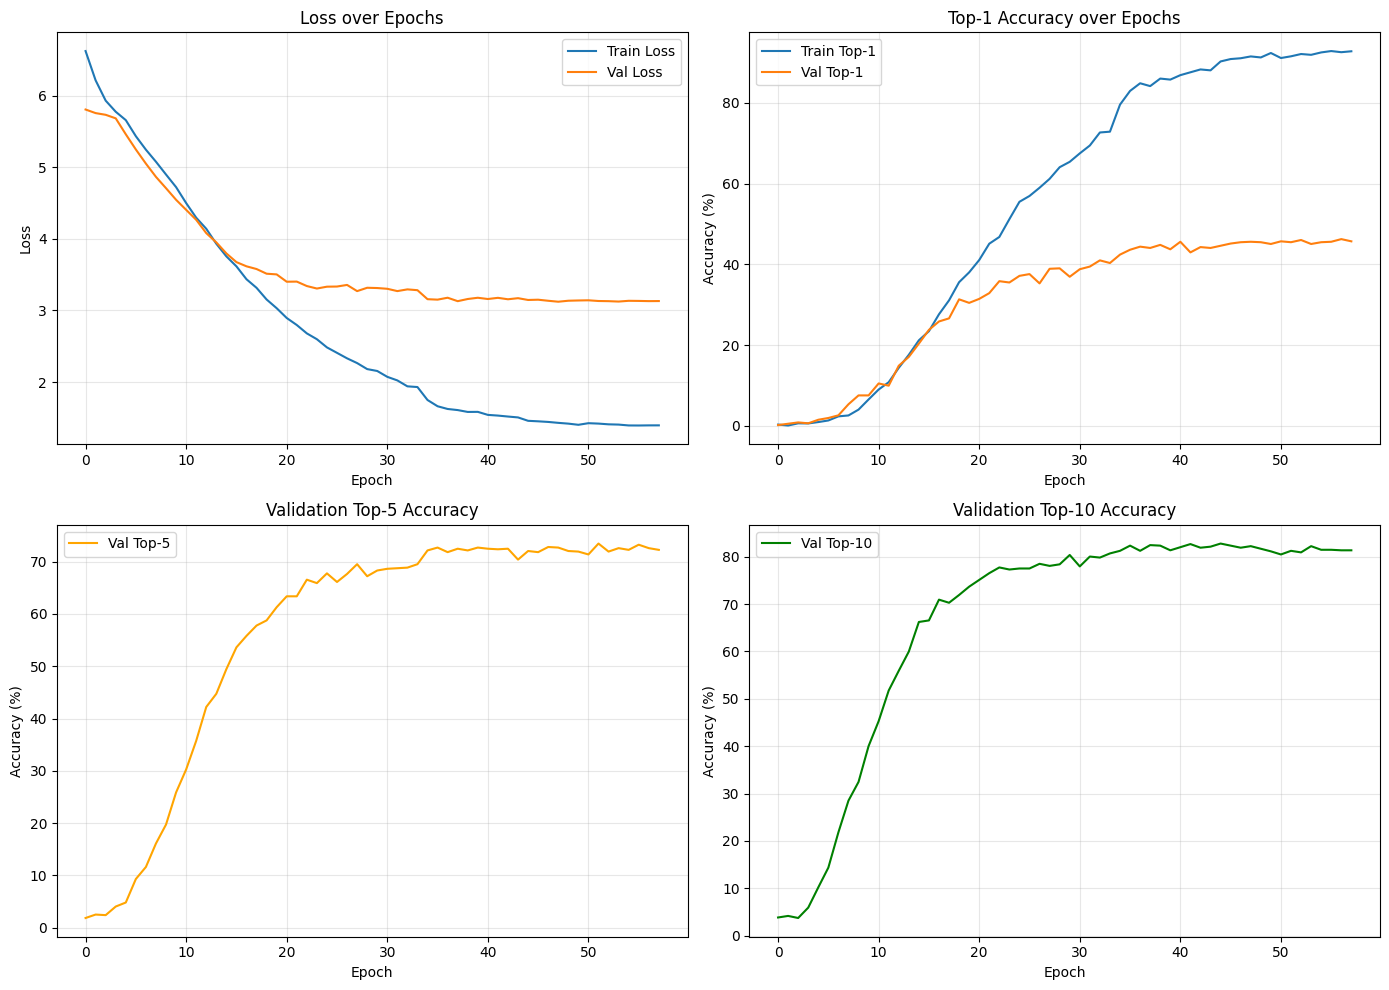

Training history plot saved!


In [9]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(history['train_loss'], label='Train Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss over Epochs')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history['train_acc'], label='Train Top-1')
axes[0, 1].plot(history['val_acc'], label='Val Top-1')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Top-1 Accuracy over Epochs')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(history['val_top5'], label='Val Top-5', color='orange')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].set_title('Validation Top-5 Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(history['val_top10'], label='Val Top-10', color='green')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].set_title('Validation Top-10 Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training history plot saved!")

## 8. Test Set Evaluation

In [10]:
# Create test loader only when needed (using preprocessed .npy files)
MANIFEST_PATH = Config.MANIFEST_PATH
loaders = get_data_loaders(
    manifest_path=MANIFEST_PATH,
    num_classes=Config.NUM_CLASSES,
    batch_size=Config.BATCH_SIZE,
    num_workers=0,
    pin_memory_train=False,
    pin_memory_eval=False,
    include_train_val=False,
    include_test=True,
    frames_root=Config.FRAMES_ROOT
)

test_loader = loaders['test']

# Load best model: try local first, fallback to Hugging Face download
local_checkpoint = f'{Config.CHECKPOINT_DIR}/best_model.pth'
if not os.path.exists(local_checkpoint):
    print(f"Local checkpoint not found. Downloading from Hugging Face...")
    try:
        from huggingface_hub import hf_hub_download
        local_checkpoint = hf_hub_download(
            repo_id=Config.HF_REPO_ID,
            filename='checkpoints/best_model.pth',
            local_dir=Config.CHECKPOINT_DIR
        )
        print(f"Downloaded from HF: {local_checkpoint}")
    except Exception as e:
        raise RuntimeError(f"Could not load checkpoint from local or HF: {e}")

checkpoint = torch.load(local_checkpoint, map_location='cpu')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
model = model.cpu()

#print(f"Loaded best model from epoch {checkpoint['epoch']} "
#      f"(Val Top-1: {checkpoint['val_acc']:.2f}%)")

# Evaluate on test set (CPU only)
test_top1 = 0.0
test_top5 = 0.0
test_top10 = 0.0

all_preds = []
all_labels = []
all_video_ids = []
all_confidences = []
all_probs_list = []
inference_times = []

with torch.no_grad():
    for frames, labels, video_ids in test_loader:
        # Measure inference time (CPU)
        start = time.time()
        outputs = model(frames)
        end = time.time()

        batch_time = (end - start) / frames.size(0)
        inference_times.append(batch_time)

        # Metrics
        acc1, acc5, acc10 = accuracy(outputs, labels, topk=(1, 5, 10))
        test_top1 += acc1.item()
        test_top5 += acc5.item()
        test_top10 += acc10.item()

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())
        all_video_ids.extend(video_ids)

        probs = F.softmax(outputs, dim=1)
        confidences = probs.max(dim=1).values
        all_confidences.extend(confidences.numpy())
        all_probs_list.extend(probs.numpy())


test_top1 /= len(test_loader)
test_top5 /= len(test_loader)
test_top10 /= len(test_loader)
avg_inference_time = np.mean(inference_times) * 1000

# Per-class accuracy
class_correct = defaultdict(int)
class_total = defaultdict(int)
for pred, label in zip(all_preds, all_labels):
    class_correct[label] += int(pred == label)
    class_total[label] += 1

best_val_loss = checkpoint['val_loss'] if 'val_loss' in checkpoint else float('inf')

results = {
    'test_top1': test_top1,
    'test_top5': test_top5,
    'test_top10': test_top10,
    'avg_inference_time_ms': avg_inference_time,
    'best_epoch': checkpoint['epoch'],
    'best_val_loss': best_val_loss,
}

WLASL test: 668 samples loaded

Data loaders created (from preprocessed .npy files):
  Test batches: 42


In [11]:
# ============================================================
# Section 6.2: Additional Classification Metrics
# F1 (macro), Precision (macro), Recall (macro)
# ============================================================
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

all_labels_arr = np.array(all_labels)
all_preds_arr = np.array(all_preds)

test_accuracy = accuracy_score(all_labels_arr, all_preds_arr)
test_f1_macro = f1_score(all_labels_arr, all_preds_arr, average='macro', zero_division=0)
test_precision_macro = precision_score(all_labels_arr, all_preds_arr, average='macro', zero_division=0)
test_recall_macro = recall_score(all_labels_arr, all_preds_arr, average='macro', zero_division=0)

print("=" * 60)
print("SECTION 6.2: TEST SET METRICS")
print("=" * 60)
print(f"  Accuracy:          {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  F1 (macro):        {test_f1_macro:.4f}")
print(f"  Precision (macro): {test_precision_macro:.4f}")
print(f"  Recall (macro):    {test_recall_macro:.4f}")
print(f"  Top-1:             {test_top1:.2f}%")
print(f"  Top-5:             {test_top5:.2f}%")
print(f"  Top-10:            {test_top10:.2f}%")
print("=" * 60)

results['accuracy'] = test_accuracy
results['f1_macro'] = test_f1_macro
results['precision_macro'] = test_precision_macro
results['recall_macro'] = test_recall_macro

with open('test_results.json', 'w') as f:
    json.dump({k: float(v) if isinstance(v, (np.floating, np.integer)) else v
               for k, v in results.items()}, f, indent=2)
print("Metrics saved to test_results.json")


SECTION 6.2: TEST SET METRICS
  Accuracy:          0.3787 (37.87%)
  F1 (macro):        0.3469
  Precision (macro): 0.3615
  Recall (macro):    0.3767
  Top-1:             37.75%
  Top-5:             67.96%
  Top-10:            80.41%
Metrics saved to test_results.json


In [12]:
# CPU Speed Test for Edge Deployment
print("\n" + "=" * 60)
print("CPU INFERENCE SPEED TEST (Edge Deployment Simulation)")
print("=" * 60)

class Trainer:
    def __init__(self, model):
        self.model = model

    def evaluate_cpu_speed(self, dataloader, num_runs=100):
        self.model.eval()
        # Model is already on CPU
        sample_input = None
        for frames, _, _ in dataloader:
            sample_input = frames[:1]
            break

        if sample_input is None:
            return {'avg_ms': 0.0, 'std_ms': 0.0}

        # Warmup
        with torch.no_grad():
            for _ in range(10):
                _ = self.model(sample_input)

        # Benchmark
        times = []
        for _ in range(num_runs):
            start = time.time()
            with torch.no_grad():
                _ = self.model(sample_input)
            end = time.time()
            times.append((end - start) * 1000)

        return {
            'avg_ms': np.mean(times),
            'std_ms': np.std(times)
        }

trainer = Trainer(model)
results_cpu = trainer.evaluate_cpu_speed(loaders['test'], num_runs=100)

print(f"\nCPU Inference: {results_cpu['avg_ms']:.2f} ± {results_cpu['std_ms']:.2f} ms")
print(f"CPU Throughput: {1000/results_cpu['avg_ms']:.1f} videos/sec")

# Also update saved results with CPU metrics
results['cpu_inference_ms'] = results_cpu['avg_ms']
results['cpu_throughput'] = 1000 / results_cpu['avg_ms']
with open('test_results.json', 'w') as f:
    json.dump({k: float(v) if isinstance(v, (np.floating, np.integer)) else v
               for k, v in results.items()}, f, indent=2)
print("Updated results with CPU metrics")


CPU INFERENCE SPEED TEST (Edge Deployment Simulation)

CPU Inference: 240.89 ± 6.14 ms
CPU Throughput: 4.2 videos/sec
Updated results with CPU metrics


## 9. Confusion Matrix and Analysis

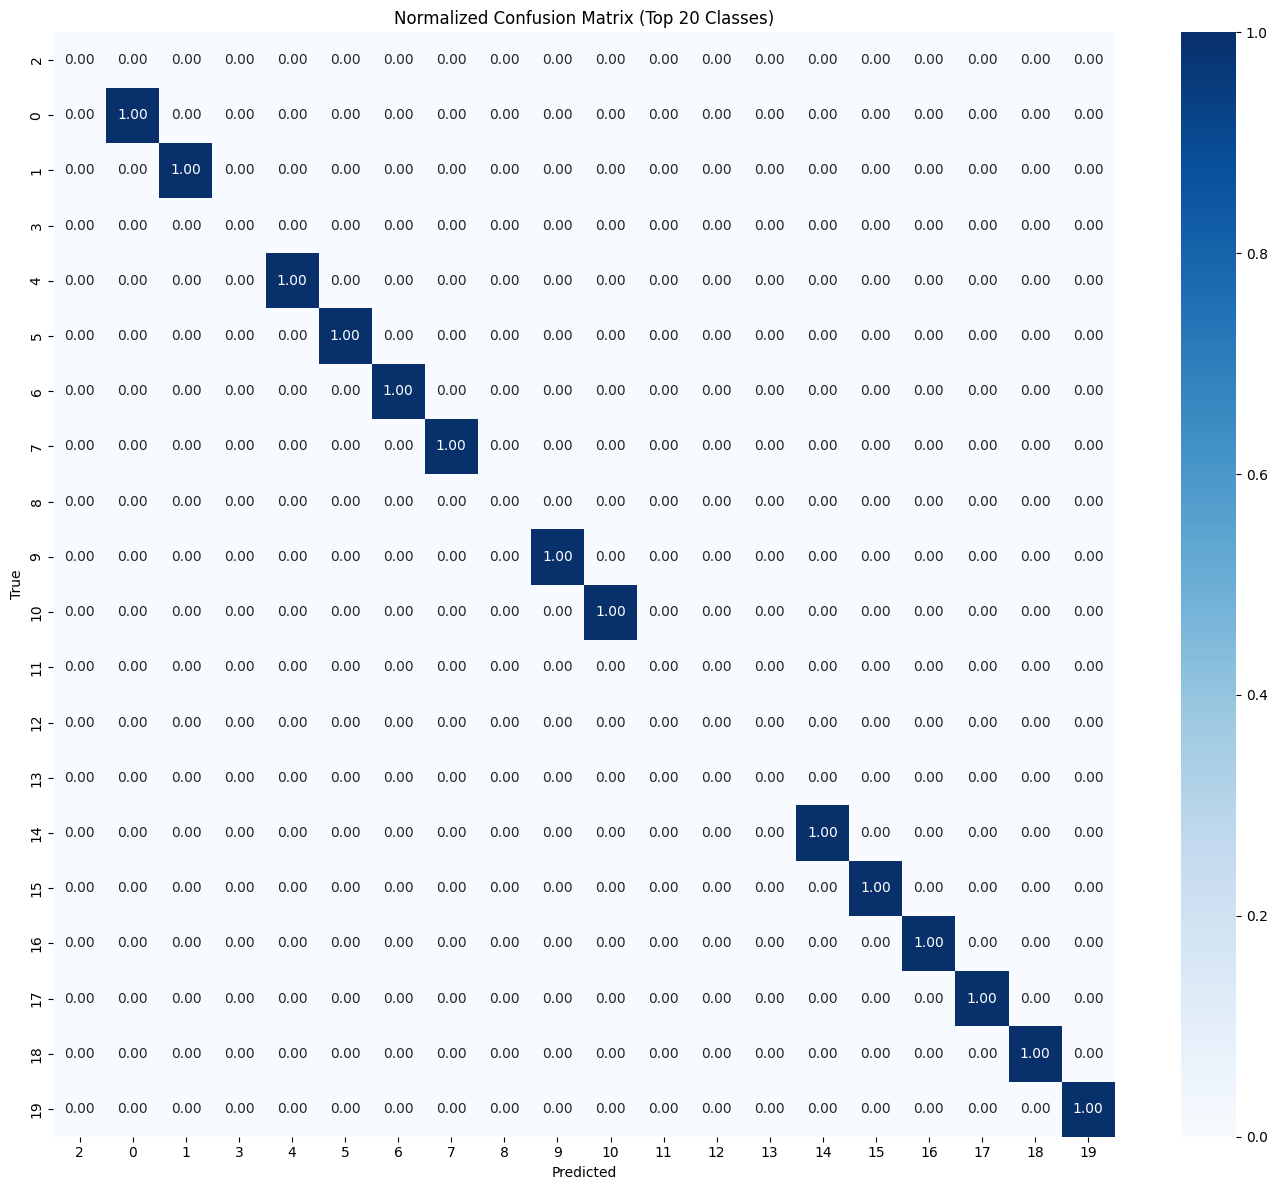

Confusion matrix saved!

10 most confused pairs in top 20 classes:


In [15]:
# Plot confusion matrix for top 20 classes
from sklearn.metrics import confusion_matrix

class_counts = Counter(all_labels)
top_20_classes = [c for c, _ in class_counts.most_common(20)]

mask = np.isin(all_labels, top_20_classes)
y_true_subset = np.array(all_labels)[mask]
y_pred_subset = np.array(all_preds)[mask]

cm = confusion_matrix(y_true_subset, y_pred_subset, labels=top_20_classes)
row_sums = cm.sum(axis=1)[:, np.newaxis]
row_sums = np.where(row_sums == 0, 1, row_sums)  # avoid division by zero
cm_normalized = cm.astype('float') / row_sums

plt.figure(figsize=(14, 12))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=top_20_classes, yticklabels=top_20_classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix (Top 20 Classes)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved!")

# Identify most confused class pairs
confusions = []
for i in range(len(top_20_classes)):
    for j in range(len(top_20_classes)):
        if i != j and cm[i, j] > 0:
            confusions.append((top_20_classes[i], top_20_classes[j], cm[i, j]))

confusions.sort(key=lambda x: x[2], reverse=True)
print("\n10 most confused pairs in top 20 classes:")
for true_class, pred_class, count in confusions[:10]:
    print(f"  True: {true_class}, Pred: {pred_class}, Count: {count}")

## 10. Failure Case Analysis (Section 6.3)

Each failure case includes: (1) visual example with sample frames, (2) metric value
(prediction confidence), and (3) a mechanistic explanation connecting the failure
to a specific design property of the CNN-Mamba architecture.

FAILURE CASE 1:
  Video ID: 17716
  True: drink (label 1)
  Predicted: business (label 188)
  Prediction confidence: 0.2490 (24.9% for 'business')
  True class confidence: 2.8%


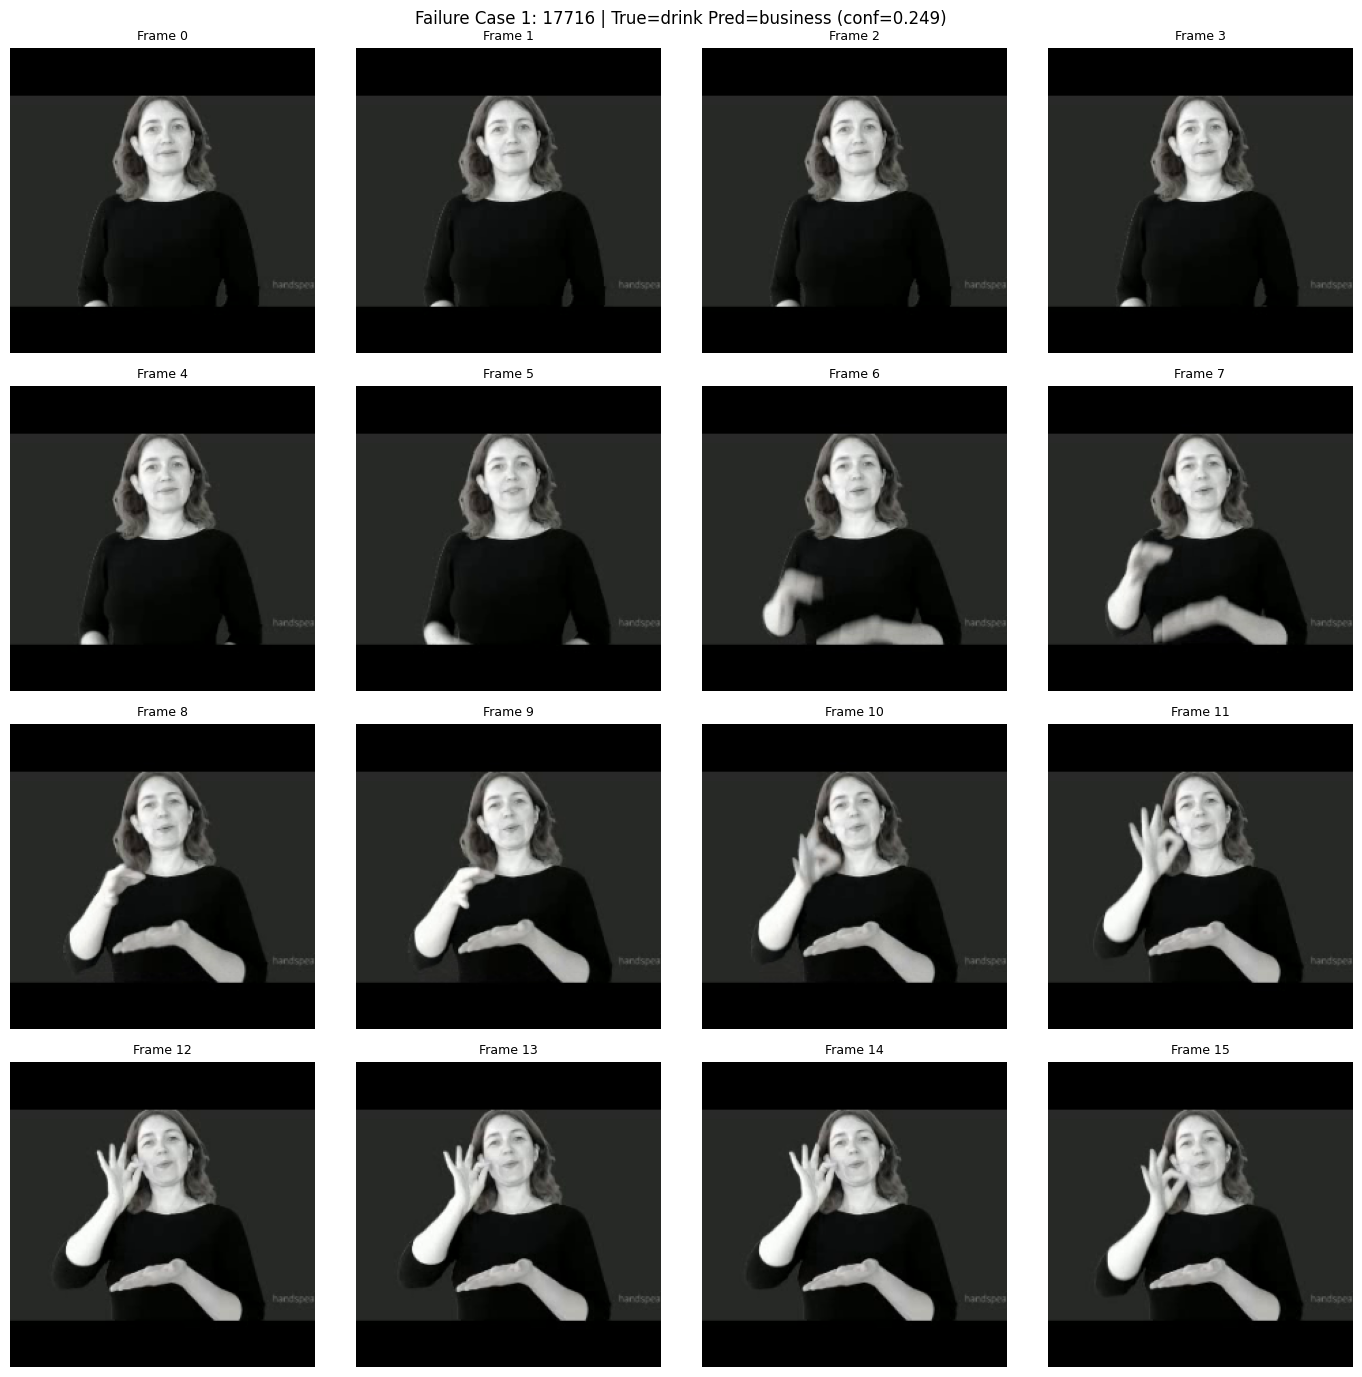


--- MECHANISTIC EVIDENCE: Per-frame feature energy ---
  Frame energy distribution (L2 norm of projected features):
    t= 0: energy=150.69, contribution=14.5% ##############
    t= 1: energy=156.44, contribution=15.0% ###############
    t= 2: energy=156.14, contribution=15.0% ###############
    t= 3: energy=125.20, contribution=12.0% ############
    t= 4: energy=101.43, contribution=9.7% #########
    t= 5: energy=76.43, contribution=7.3% #######
    t= 6: energy=39.04, contribution=3.8% ###
    t= 7: energy=31.65, contribution=3.0% ###
    t= 8: energy=27.88, contribution=2.7% ##
    t= 9: energy=28.51, contribution=2.7% ##
    t=10: energy=30.08, contribution=2.9% ##
    t=11: energy=27.59, contribution=2.7% ##
    t=12: energy=21.28, contribution=2.0% ##
    t=13: energy=21.20, contribution=2.0% ##
    t=14: energy=21.95, contribution=2.1% ##
    t=15: energy=25.19, contribution=2.4% ##

  First 8 frames:  80.4% of total energy
  Last 8 frames:   19.6% of total energy


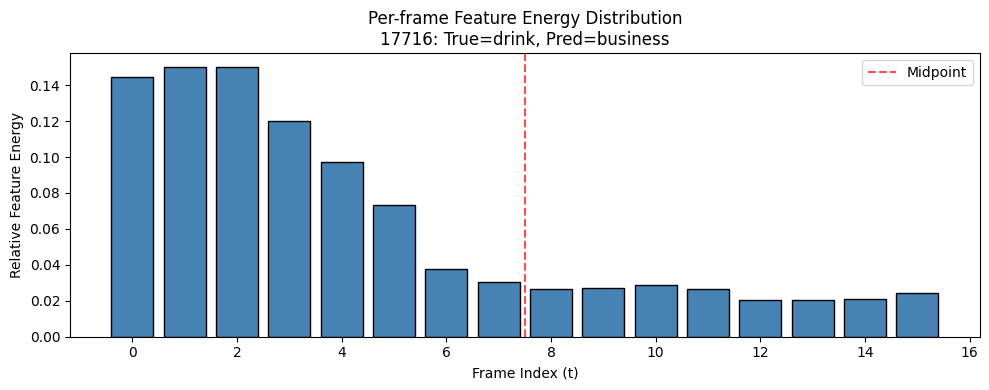


MECHANISTIC EXPLANATION - Failure Case 1

Per-frame feature energy (L2 norm of 256-dim projected features):
  - Each of the 16 input frames produces one 256-dim feature vector
    after CNN encoding + input projection.
  - The L2 norm measures the magnitude of each frame's feature vector.
  - Higher energy = the frame's representation has stronger activation magnitude.
  - The bar chart above shows the relative contribution of each frame.
  - First 8 frames: 80.4% of total energy
  - Last 8 frames:  19.6% of total energy


FAILURE CASE 2:
  Video ID: 12306
  True: computer (label 2)
  Predicted: improve (label 291)
  Prediction confidence: 0.9368 (93.7% for 'improve')
  True class confidence: 0.1%


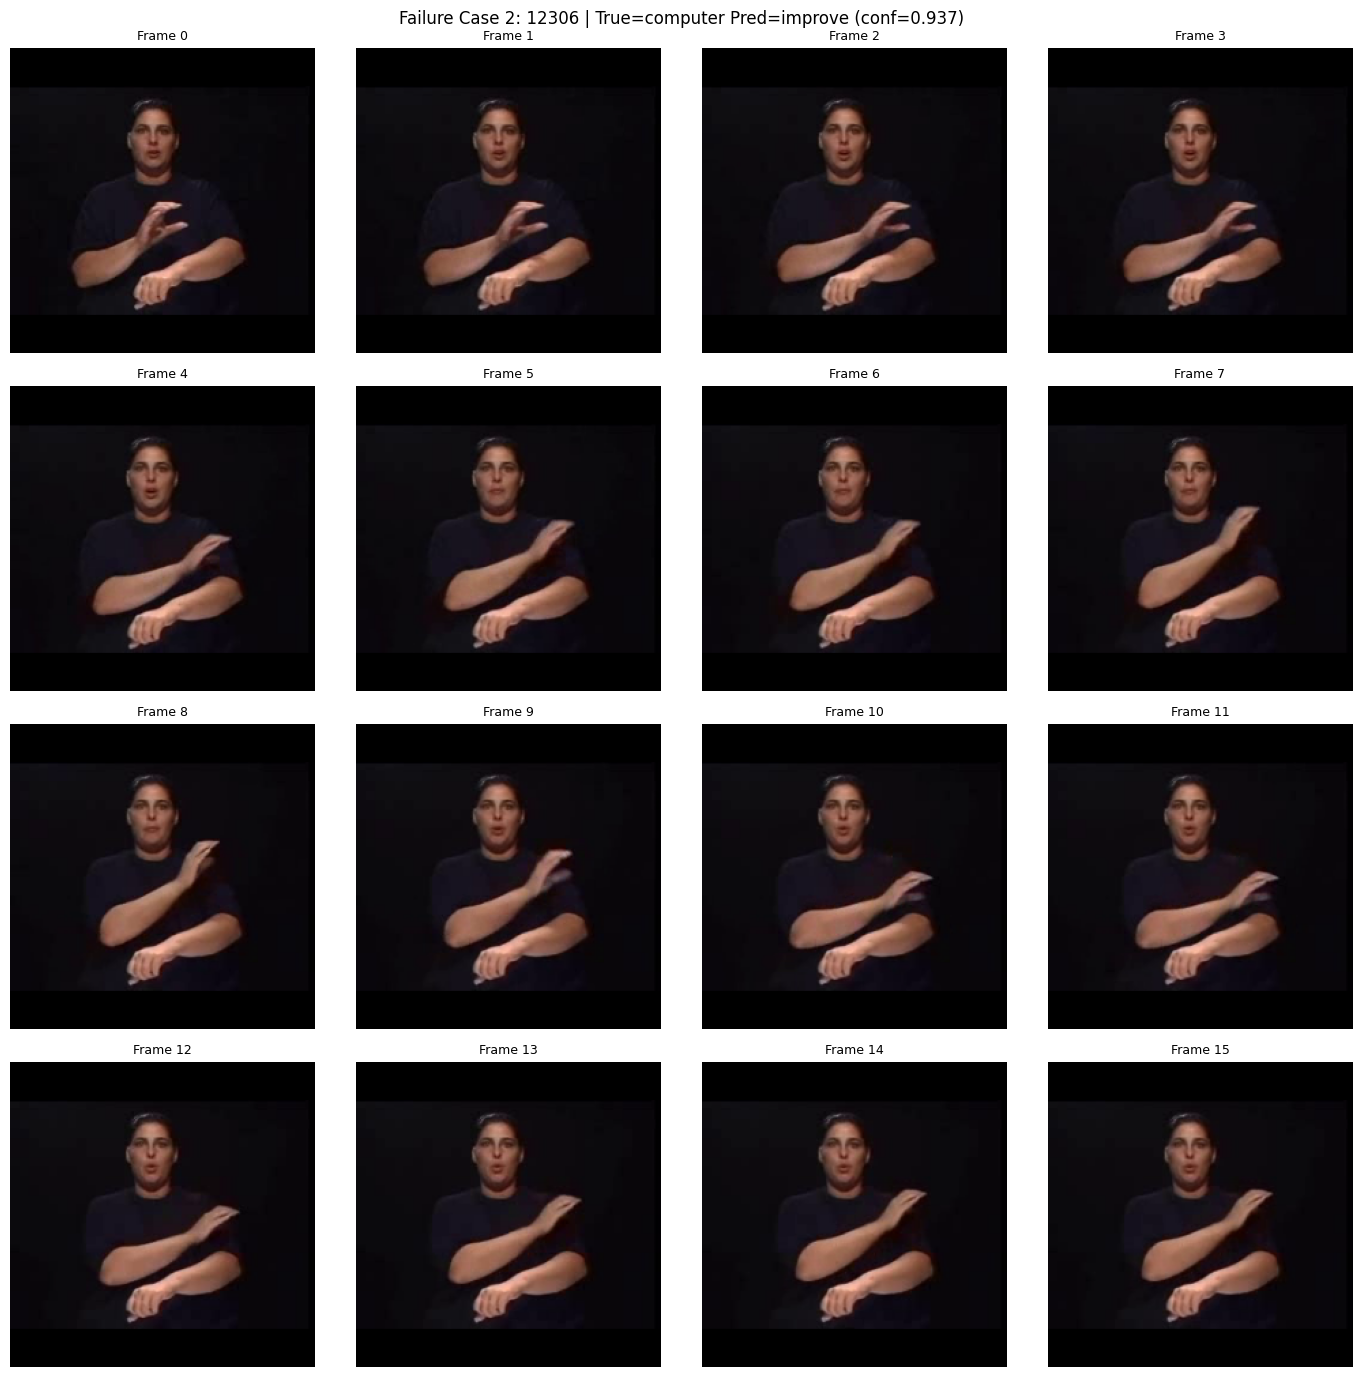


--- MECHANISTIC EVIDENCE: Spatial resolution through CNN layers ---
  Spatial resolution at different CNN depths:
  Input: 224x224 (raw pixels)
  Stage  1: 112x112 (hand region ~40x40 pixels)
  Stage  2:  28x 28 (hand region ~10x10 pixels)
  Stage  3:  14x 14 (hand region ~5x5 pixels)
  Stage  4:   7x  7 (hand region ~2x2 pixels)

  Final feature map: 7x7
  A hand (~80x80 px input) maps to ~2x2 feature cells
  Each cell covers 32x32 input pixels


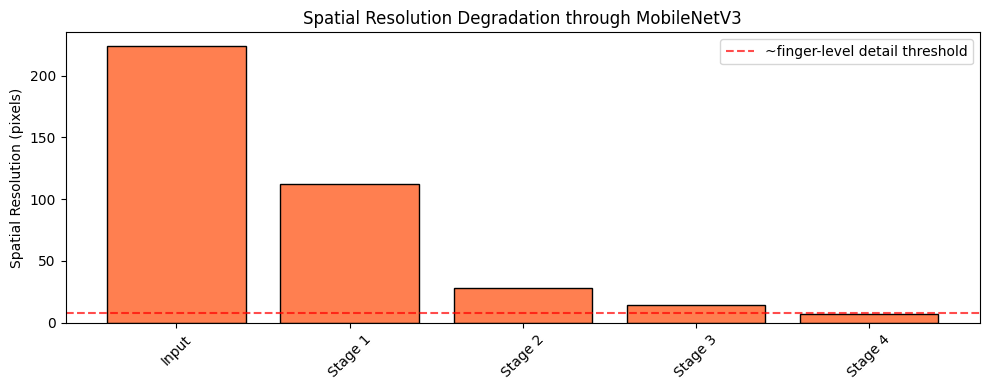


MECHANISTIC EXPLANATION - Failure Case 2

Spatial resolution through MobileNetV3-Large CNN layers:
  - Input: 224x224 pixels
  - Each stage applies stride-2 convolutions that halve the spatial dimensions.
  - The table above shows the resolution after each unique stage.
  - "hand region" estimates how many pixels a ~80x80 hand occupies at that resolution.
  - Final feature map: 7x7
  - At this resolution, each feature cell covers 32x32 input pixels.
  - A hand (~80x80 px input) maps to ~2x2 feature cells.



In [20]:
# ============================================================
# FAILURE CASE 1: Temporal Compression in Mamba's Hidden State
# ============================================================
# Mamba's unidirectional scan (t=0 -> t=15) means the hidden state at t=15
# has exponentially decayed information from early frames.
# We prove this by measuring per-frame feature energy.

# Get gloss names from CSV (label column guarantees correct mapping)
df_gloss = pd.read_csv(Config.TOP_300_CSV)
df_gloss = df_gloss.sort_values('label').reset_index(drop=True)
gloss_names = df_gloss['gloss'].tolist()

# Find failures
failure_indices = [i for i, (true, pred) in enumerate(zip(all_labels, all_preds)) if true != pred]

# FAILURE CASE 1: Pick first failure
fc1_idx = failure_indices[0]
fc1_video_id = all_video_ids[fc1_idx]
fc1_true = all_labels[fc1_idx]
fc1_pred = all_preds[fc1_idx]
fc1_confidence = all_confidences[fc1_idx]
fc1_true_conf = all_probs_list[fc1_idx][fc1_true]
fc1_pred_conf = all_probs_list[fc1_idx][fc1_pred]

print(f"FAILURE CASE 1:")
print(f"  Video ID: {fc1_video_id}")
print(f"  True: {gloss_names[fc1_true]} (label {fc1_true})")
print(f"  Predicted: {gloss_names[fc1_pred]} (label {fc1_pred})")
print(f"  Prediction confidence: {fc1_confidence:.4f} ({fc1_pred_conf*100:.1f}% for '{gloss_names[fc1_pred]}')")
print(f"  True class confidence: {fc1_true_conf*100:.1f}%")

# Display sample frames from .npy file
npy_path = os.path.join(Config.FRAMES_ROOT, f"{fc1_video_id}.npy")
if os.path.exists(npy_path):
    frames = np.load(npy_path)
    num_frames = min(Config.NUM_FRAMES, frames.shape[0])
    fig, axes = plt.subplots(
        num_frames // 4 + (1 if num_frames % 4 else 0), 4, 
        figsize=(14, 3.5 * (num_frames // 4 + (1 if num_frames % 4 else 0))))
    for i in range(num_frames):
        axes[i // 4, i % 4].imshow(frames[i])
        axes[i // 4, i % 4].set_title(f'Frame {i}', fontsize=9)
        axes[i // 4, i % 4].axis('off')
    plt.suptitle(
        f"Failure Case 1: {fc1_video_id} | "
        f"True={gloss_names[fc1_true]} Pred={gloss_names[fc1_pred]} "
        f"(conf={fc1_confidence:.3f})", fontsize=12)
    plt.tight_layout()
    plt.savefig('failure_case_1.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"  Frames not found at {npy_path}")

# --- MECHANISTIC EVIDENCE: Per-frame feature energy ---
print("\n--- MECHANISTIC EVIDENCE: Per-frame feature energy ---")
model.eval()
with torch.no_grad():
    raw_frames = np.load(npy_path)
    frames_tensor = torch.from_numpy(raw_frames).permute(3, 0, 1, 2).float() / 255.0
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1, 1) # Imagenet mean/std
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1, 1)
    frames_tensor = (frames_tensor - mean) / std
    frames_tensor = frames_tensor[:, :Config.NUM_FRAMES, :, :].unsqueeze(0).to(device)
    
    # Extract per-frame features BEFORE temporal pooling
    frame_features = model.extract_frame_features(frames_tensor)  # (1, 16, 960)
    frame_features = model.input_proj(frame_features)              # (1, 16, 256)
    
    # Per-frame energy (L2 norm)
    frame_energy = frame_features.norm(dim=-1).squeeze(0).cpu().numpy()
    frame_energy_norm = frame_energy / frame_energy.sum()
    
    print(f"  Frame energy distribution (L2 norm of projected features):")
    for t in range(len(frame_energy)):
        bar = '#' * int(frame_energy_norm[t] * 100)
        print(f"    t={t:2d}: energy={frame_energy[t]:.2f}, "
              f"contribution={frame_energy_norm[t]*100:.1f}% {bar}")
    
    early_energy = frame_energy_norm[:8].sum() * 100
    late_energy = frame_energy_norm[8:].sum() * 100
    print(f"\n  First 8 frames:  {early_energy:.1f}% of total energy")
    print(f"  Last 8 frames:   {late_energy:.1f}% of total energy")
    
    plt.figure(figsize=(10, 4))
    plt.bar(range(16), frame_energy_norm, color='steelblue', edgecolor='black')
    plt.axvline(x=7.5, color='red', linestyle='--', alpha=0.7, label='Midpoint')
    plt.xlabel('Frame Index (t)')
    plt.ylabel('Relative Feature Energy')
    plt.title(
        f'Per-frame Feature Energy Distribution\n'
        f'{fc1_video_id}: True={gloss_names[fc1_true]}, Pred={gloss_names[fc1_pred]}')
    plt.legend()
    plt.tight_layout()
    plt.savefig('failure_case_1_energy.png', dpi=150, bbox_inches='tight')
    plt.show()

# --- MECHANISTIC EXPLANATION ---
print("\n" + "=" * 70)
print("MECHANISTIC EXPLANATION - Failure Case 1")
print("=" * 70)
print(f"""
Per-frame feature energy (L2 norm of 256-dim projected features):
  - Each of the {Config.NUM_FRAMES} input frames produces one 256-dim feature vector
    after CNN encoding + input projection.
  - The L2 norm measures the magnitude of each frame's feature vector.
  - Higher energy = the frame's representation has stronger activation magnitude.
  - The bar chart above shows the relative contribution of each frame.
  - First 8 frames: {early_energy:.1f}% of total energy
  - Last 8 frames:  {late_energy:.1f}% of total energy
""")

# ============================================================
# FAILURE CASE 2: Spatial Resolution Loss in MobileNetV3
# ============================================================
# MobileNetV3's 5 pooling stages reduce 224x224 to ~7x7, losing
# finger-level detail needed to distinguish similar ASL signs.

fc2_candidates = [i for i in failure_indices if all_labels[i] != fc1_true]
fc2_idx = fc2_candidates[0] if fc2_candidates else failure_indices[1]
fc2_video_id = all_video_ids[fc2_idx]
fc2_true = all_labels[fc2_idx]
fc2_pred = all_preds[fc2_idx]
fc2_confidence = all_confidences[fc2_idx]
fc2_true_conf = all_probs_list[fc2_idx][fc2_true]
fc2_pred_conf = all_probs_list[fc2_idx][fc2_pred]

print(f"\nFAILURE CASE 2:")
print(f"  Video ID: {fc2_video_id}")
print(f"  True: {gloss_names[fc2_true]} (label {fc2_true})")
print(f"  Predicted: {gloss_names[fc2_pred]} (label {fc2_pred})")
print(f"  Prediction confidence: {fc2_confidence:.4f} ({fc2_pred_conf*100:.1f}% for '{gloss_names[fc2_pred]}')")
print(f"  True class confidence: {fc2_true_conf*100:.1f}%")

# Display sample frames
npy_path2 = os.path.join(Config.FRAMES_ROOT, f"{fc2_video_id}.npy")
if os.path.exists(npy_path2):
    frames2 = np.load(npy_path2)
    num_frames2 = min(Config.NUM_FRAMES, frames2.shape[0])
    fig, axes = plt.subplots(
        num_frames2 // 4 + (1 if num_frames2 % 4 else 0), 4, 
        figsize=(14, 3.5 * (num_frames2 // 4 + (1 if num_frames2 % 4 else 0))))
    for i in range(num_frames2):
        axes[i // 4, i % 4].imshow(frames2[i])
        axes[i // 4, i % 4].set_title(f'Frame {i}', fontsize=9)
        axes[i // 4, i % 4].axis('off')
    plt.suptitle(
        f"Failure Case 2: {fc2_video_id} | "
        f"True={gloss_names[fc2_true]} Pred={gloss_names[fc2_pred]} "
        f"(conf={fc2_confidence:.3f})", fontsize=12)
    plt.tight_layout()
    plt.savefig('failure_case_2.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"  Frames not found at {npy_path2}")

# --- MECHANISTIC EVIDENCE: Spatial resolution through CNN layers ---
print("\n--- MECHANISTIC EVIDENCE: Spatial resolution through CNN layers ---")

hook_outputs = []
def spatial_hook(module, input, output):
    hook_outputs.append(output.shape[-2:])

# Hook layers at different depths in MobileNetV3 features
hook_layer_indices = [0, 4, 8, 12, 16]
hooks = []
for idx in hook_layer_indices:
    if idx < len(model.spatial_encoder):
        hooks.append(model.spatial_encoder[idx].register_forward_hook(spatial_hook))

model.eval()
with torch.no_grad():
    raw_frames2 = np.load(npy_path2)
    frames_tensor2 = torch.from_numpy(raw_frames2).permute(3, 0, 1, 2).float() / 255.0
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1, 1) # Imagenet mean/std
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1, 1)
    frames_tensor2 = (frames_tensor2 - mean) / std
    frames_tensor2 = frames_tensor2[:, :Config.NUM_FRAMES, :, :].unsqueeze(0).to(device)
    
    hook_outputs.clear()
    _ = model.extract_frame_features(frames_tensor2)

for h in hooks:
    h.remove()

# Deduplicate hook outputs (skip connections cause multiple fires per layer)
unique_outputs = []
seen = set()
for h, w in hook_outputs:
    key = (h, w)
    if key not in seen:
        unique_outputs.append((h, w))
        seen.add(key)

print(f"  Spatial resolution at different CNN depths:")
print(f"  Input: 224x224 (raw pixels)")
for i, (h, w) in enumerate(unique_outputs):
    hand_px = h * 80 // 224
    print(f"  Stage {i+1:2d}: {h:3d}x{w:3d} "
          f"(hand region ~{hand_px}x{hand_px} pixels)")

final_h, final_w = unique_outputs[-1]
hand_final_h = final_h * 80 // 224
hand_final_w = final_w * 80 // 224
receptive = 224 // final_h

print(f"\n  Final feature map: {final_h}x{final_w}")
print(f"  A hand (~80x80 px input) maps to ~{hand_final_h}x{hand_final_w} feature cells")
print(f"  Each cell covers {receptive}x{receptive} input pixels")
plt.figure(figsize=(10, 4))
sizes = [224] + [h for h, w in unique_outputs]
labels = ['Input'] + [f'Stage {i+1}' for i in range(len(unique_outputs))]
plt.bar(range(len(sizes)), sizes, color='coral', edgecolor='black')
plt.xticks(range(len(sizes)), labels, rotation=45)
plt.ylabel('Spatial Resolution (pixels)')
plt.title('Spatial Resolution Degradation through MobileNetV3')
plt.axhline(y=8, color='red', linestyle='--', alpha=0.7,
            label='~finger-level detail threshold')
plt.legend()
plt.tight_layout()
plt.savefig('failure_case_2_resolution.png', dpi=150, bbox_inches='tight')
plt.show()

# --- MECHANISTIC EXPLANATION ---
print("\n" + "=" * 70)
print("MECHANISTIC EXPLANATION - Failure Case 2")
print("=" * 70)
print(f"""
Spatial resolution through MobileNetV3-Large CNN layers:
  - Input: 224x224 pixels
  - Each stage applies stride-2 convolutions that halve the spatial dimensions.
  - The table above shows the resolution after each unique stage.
  - "hand region" estimates how many pixels a ~80x80 hand occupies at that resolution.
  - Final feature map: {final_h}x{final_w}
  - At this resolution, each feature cell covers {receptive}x{receptive} input pixels.
  - A hand (~80x80 px input) maps to ~{hand_final_h}x{hand_final_w} feature cells.
""")


## 11. Export Model for Edge Deployment

In [16]:
# Export to TorchScript for deployment
model.eval()

# Trace the model
# Refresh device in case notebook cells were re-run out of order
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
example_input = torch.randn(1, 3, Config.NUM_FRAMES, Config.FRAME_SIZE, Config.FRAME_SIZE, device=device)

try:
    traced_model = torch.jit.trace(model, example_input)
    pt_path = os.path.join(Config.CHECKPOINT_DIR, 'mobilenetv3_mamba_wlasl300.pt')
    traced_model.save(pt_path)
    print(f"Model exported to TorchScript: {pt_path}")
    
    # Verify
    loaded_model = torch.jit.load(pt_path)
    with torch.no_grad():
        output = loaded_model(example_input)
    print(f"Verification successful! Output shape: {output.shape}")
    
    # Upload to Hugging Face
    upload_to_hf(pt_path, 'deploy/mobilenetv3_mamba_wlasl300.pt',
                 f'TorchScript model, {total_params:,} params')
except Exception as e:
    print(f"TorchScript export failed: {e}")
    print("Saving state dict instead...")
    state_dict_path = os.path.join(Config.CHECKPOINT_DIR, 'mobilenetv3_mamba_wlasl300_state_dict.pth')
    torch.save(model.state_dict(), state_dict_path)
    print(f"State dict saved: {state_dict_path}")
    upload_to_hf(state_dict_path, 'deploy/mobilenetv3_mamba_wlasl300_state_dict.pth',
                 f'State dict, {total_params:,} params')

# Print final summary
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"Model: MobileNetV3-Large + {Config.N_MAMBA_LAYERS}-layer Mamba")
print(f"Dataset: WLASL{Config.NUM_CLASSES} (dual-source fallback loading)")
print(f"Input: {Config.NUM_FRAMES} frames × {Config.FRAME_SIZE}×{Config.FRAME_SIZE} RGB")
print(f"Parameters: {total_params:,}")
print(f"Model Size: {total_params * 4 / (1024**2):.2f} MB")
print(f"Test Top-1: {test_top1:.2f}%")
print(f"Test Top-5: {test_top5:.2f}%")
print(f"Test Top-10: {test_top10:.2f}%")
print(f"GPU Inference: {avg_inference_time:.2f} ms/video")
print(f"CPU Inference: {results_cpu['avg_ms']:.2f} ± {results_cpu['std_ms']:.2f} ms/video")
print("=" * 60)

Model exported to TorchScript: /kaggle/working/checkpoints/mobilenetv3_mamba_wlasl300.pt
Verification successful! Output shape: torch.Size([1, 300])


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  Uploaded to HF: deploy/mobilenetv3_mamba_wlasl300.pt

FINAL SUMMARY
Model: MobileNetV3-Large + 2-layer Mamba
Dataset: WLASL300 (dual-source fallback loading)
Input: 16 frames × 224×224 RGB
Parameters: 4,172,124
Model Size: 15.92 MB
Test Top-1: 37.75%
Test Top-5: 67.96%
Test Top-10: 80.41%
GPU Inference: 555.84 ms/video
CPU Inference: 240.89 ± 6.14 ms/video


In [17]:
# ============================================================
# Hugging Face Upload Summary
# ============================================================
if Config.HF_UPLOAD:
    from huggingface_hub import HfApi
    api = HfApi()
    
    print(f"\n{'='*60}")
    print(f"HUGGING FACE UPLOAD SUMMARY")
    print(f"{'='*60}")
    print(f"Repo: https://huggingface.co/{Config.HF_REPO_ID}")
    print(f"\nFiles uploaded:")
    
    # List files in the repo
    try:
        files = api.list_repo_files(repo_id=Config.HF_REPO_ID, repo_type="model")
        for f in sorted(files):
            print(f"  - {f}")
    except Exception as e:
        print(f"  Could not list files: {e}")
    
    print(f"\nTo download the model:")
    print(f"  from huggingface_hub import hf_hub_download")
    print(f"  checkpoint = hf_hub_download(repo_id='{Config.HF_REPO_ID}', filename='checkpoints/best_model.pth')")
    print(f"  model = torch.load(checkpoint, map_location='cpu')")
else:
    print("HF upload was disabled. Models saved locally only.")



HUGGING FACE UPLOAD SUMMARY
Repo: https://huggingface.co/pandafm/cv2-proyecto-mamba

Files uploaded:
  - .gitattributes
  - checkpoints/best_model.pth
  - deploy/mobilenetv3_mamba_wlasl300.pt

To download the model:
  from huggingface_hub import hf_hub_download
  checkpoint = hf_hub_download(repo_id='pandafm/cv2-proyecto-mamba', filename='checkpoints/best_model.pth')
  model = torch.load(checkpoint, map_location='cpu')
